<a href="https://colab.research.google.com/github/mitski-1/aiml/blob/main/lab2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer

In [ ]:
#Reading the file
df = pd.read_csv('/titanic.csv')

In [ ]:
df["Age"].head(10)
df.head()
df.describe(include=[int])
df.describe(exclude=[int])
df.info()
df.isna().sum()
df.isnull()
df.isnull().sum()
df["Age"].mean().round(2)

In [ ]:
#slicing
df.columns[2:12]

In [ ]:
df.columns

In [ ]:
df["Survived"].value_counts()

In [ ]:
print("Duplicate rows:", df.duplicated())
print("Duplicate rows:", df.duplicated().sum())


In [ ]:
print("Age:",df["Age"].head(8))

In [ ]:
print("Missing Values:", df["Age"].isna().sum())

In [ ]:
print("Misising values:", df["Age"].isnull().sum())

In [ ]:
print("Missing Values:", df.columns.isnull().sum())

In [ ]:
print("most commmon tickets:", df["Ticket"].value_counts().head(5))

In [ ]:
print("gender survival rate:",df['Gender'].value_counts(), df['Survived'].value_counts())

In [ ]:
df.info(4)

In [ ]:
df.describe(include=[int])

In [ ]:
df.describe(exclude=[int])

In [ ]:
df.isna().sum()

In [ ]:
print("Missing Values:",df["Age"].isna().sum())

In [ ]:
print("age:",df["Age"].head(5))

In [ ]:
print("shape(rows,columns):",df.shape)

In [ ]:
df["Age"].mean().round(0)

In [ ]:
df["Survived"].value_counts(normalize=True)*100

In [ ]:
df.columns[3:11]

In [ ]:
df.duplicated().sum()
print("Duplicate rows:",df.duplicated().sum())

In [ ]:
# applying imputation strategy to fill missing numerical values
df1=df.copy()
df.head()

In [ ]:
df1["Age"].isnull().sum()
print("Missing Values:",df1["Age"])

In [ ]:
df1["Age"],df1["Age"].fillna(df1["Age"].mean())
print("Mssing Age before:",df1["Age"].isna().sum())

In [ ]:
df2=df1.copy()
num_imputer = SimpleImputer(strategy='median')
df2["Age"]=num_imputer.fit_transform(df2[["Age"]])
num_imputer.fit(df2[["Age"]])
print(num_imputer.statistics_)

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer

In [ ]:
df=pd.read_csv('/titanic.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.nunique()

,0
PassengerId,891
Survived,2
Pclass,3
Name,891
Gender,2
Age,88
SibSp,7
Parch,7
Ticket,681
Fare,248


In [ ]:
df.loc[0,"Age"]

np.float64(22.0)

In [ ]:
df.isnull().head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False


In [ ]:
print(df["Embarked"].nunique())

3


In [ ]:
fare=df["Fare"].dropna()
print(type(fare))
print("Orignal rows:",len(df))
print("Missing fare:",df)

<class 'pandas.core.series.Series'>
Orignal rows: 891
Missing fare:      PassengerId  Survived  Pclass  ...     Fare Cabin  Embarked
0              1         0       3  ...   7.2500   NaN         S
1              2         1       1  ...  71.2833   C85         C
2              3         1       3  ...   7.9250   NaN         S
3              4         1       1  ...  53.1000  C123         S
4              5         0       3  ...   8.0500   NaN         S
..           ...       ...     ...  ...      ...   ...       ...
886          887         0       2  ...  13.0000   NaN         S
887          888         1       1  ...  30.0000   B42         S
888          889         0       3  ...  23.4500   NaN         S
889          890         1       1  ...  30.0000  C148         C
890          891         0       3  ...   7.7500   NaN         Q

[891 rows x 12 columns]


In [ ]:
df['Age'].isnull().sum()

np.int64(177)

In [ ]:
print("fare non-missing:",len(fare))

fare non-missing: 891


In [ ]:
Q1 =fare.quantile(0.25)
Q3=fare.quantile(0.75)

In [ ]:
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
print("Lower:",lower_bound, "Upper:",upper_bound)

Lower: -26.724 Upper: 65.6344


In [ ]:
outliers=df[(df["Fare"]<lower_bound)|(df["Fare"]>upper_bound)]
print("outliers count:",len(outliers))
outliers


outliers count: 116


,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,NaN,1,0,PC 17569,146.5208,B78,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,NaN,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,D33,C
...,...,...,...,...,...,...,...,...,...,...,...,...
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.5500,NaN,S
849,850,1,1,"Goldenberg, Mrs. Samuel L (Edwiga Grabowska)",female,NaN,1,0,17453,89.1042,C92,C
856,857,1,1,"Wick, Mrs. George Dennick (Mary Hitchcock)",female,45.0,1,1,36928,164.8667,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.5500,NaN,S


In [ ]:
print("orignal rows:",len(df))
df["Cabin"].isna().sum()


orignal rows: 891


np.int64(687)

In [ ]:
print(df["Embarked"].nunique())
print(df["Age"].nunique())
print(df["Pclass"].nunique())
print(df["Gender"].nunique())

3
88
3
2


In [ ]:
print(df["Gender"].unique())
print(df["Embarked"].unique())
print("missing Gender:",df["Gender"].isna().sum())
print("missing embarked:",df["Embarked"].isna().sum())
df["embarked_enc"] =df["Embarked"].map({"S":0,"C":1})

['male' 'female']
['S' 'C' 'Q' nan]
missing Gender: 0
missing embarked: 2


In [ ]:
df["embarked_enc"] =df["Embarked"].map({"S":0,"C":1})
df["embarked_enc"]

,embarked_enc
0,0.0
1,1.0
2,0.0
3,0.0
4,0.0
...,...
886,0.0
887,0.0
888,0.0
889,1.0


In [ ]:
print("missing embarked:",df["Embarked"].isna().sum())


missing embarked: 2


In [ ]:
df = pd.read_csv('/titanic.csv')

In [ ]:
df["embarked_enc"] =df["Embarked"].map({"S":0,"C":1})



In [ ]:
df[["Embarked","embarked_enc"]].head()

,Embarked,embarked_enc
0,S,0.0
1,C,1.0
2,S,0.0
3,S,0.0
4,S,0.0


In [ ]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'embarked_enc'],
      dtype='object')


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


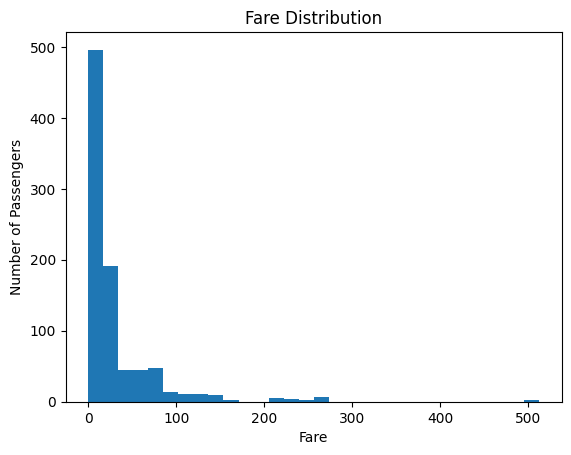

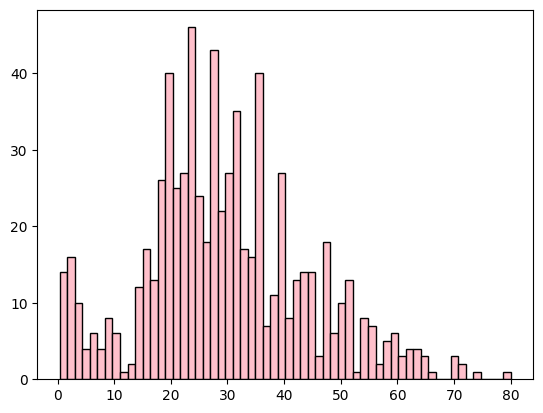

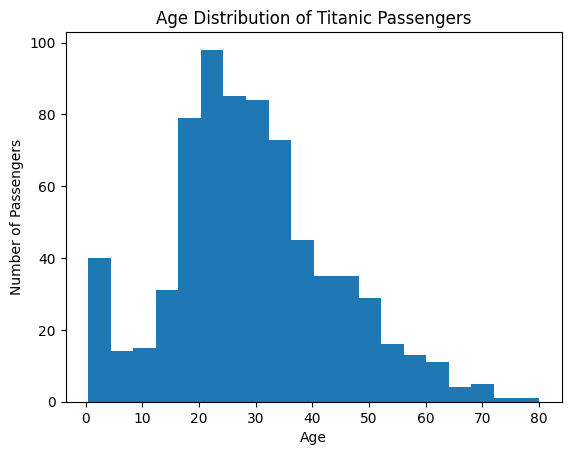

In [ ]:
plt.figure()
plt.hist(df['Fare'], bins=30)
plt.xlabel('Fare')
plt.ylabel('Number of Passengers')
plt.title('Fare Distribution')
plt.show()
plt.hist(df['Age'].dropna(),
         bins=60,
         color='pink',
         edgecolor='black')

plt.figure()
plt.hist(df['Age'].dropna(), bins=20)
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.title('Age Distribution of Titanic Passengers')
plt.show()


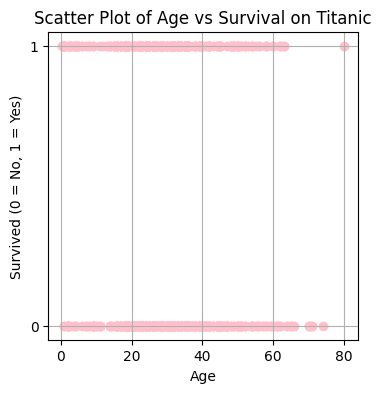

In [ ]:
plt.figure(figsize=(4, 4))
plt.scatter(df['Age'],
            df['Survived'],
            alpha=1,
            color='pink')

plt.xlabel('Age')
plt.ylabel('Survived (0 = No, 1 = Yes)')
plt.title('Scatter Plot of Age vs Survival on Titanic')

plt.yticks([0, 1])
plt.grid(True, linestyle='-', alpha=1)

plt.show()

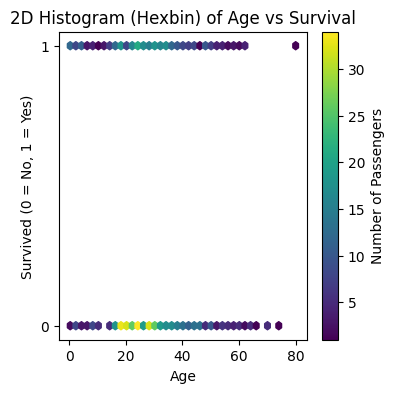

In [ ]:

plt.figure(figsize=(4, 4))

hb = plt.hexbin(df['Age'],
                df['Survived'],
                gridsize=40,
                cmap='viridis',
                mincnt=1)

plt.xlabel('Age')
plt.ylabel('Survived (0 = No, 1 = Yes)')
plt.title('2D Histogram (Hexbin) of Age vs Survival')

plt.yticks([0, 1])
plt.colorbar(hb, label='Number of Passengers')

plt.show()

In [ ]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])


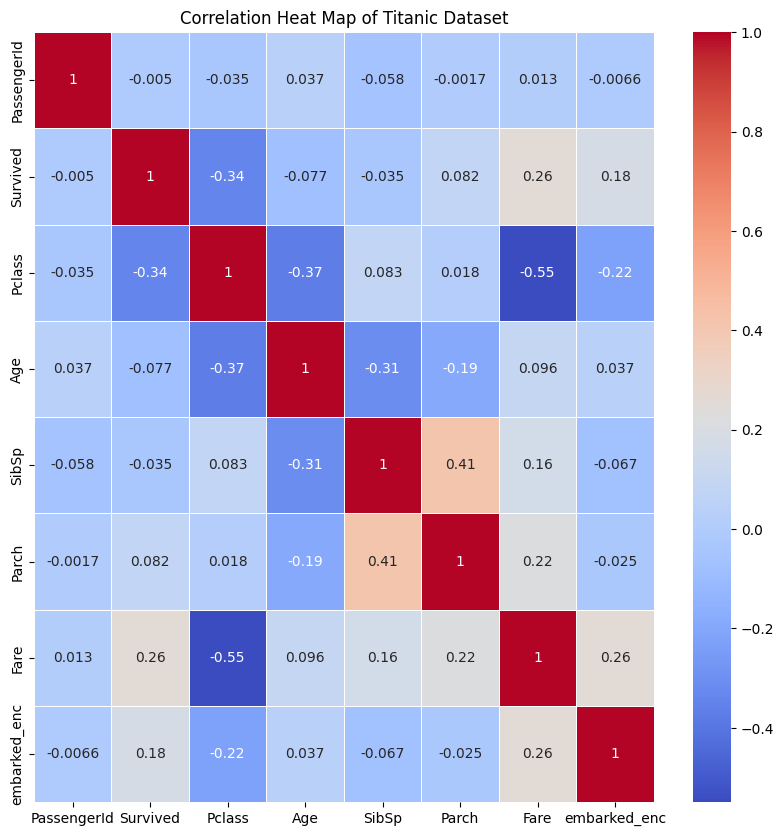

In [ ]:
plt.figure(figsize=(10, 10))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm',
            linewidths=0.5)

plt.title('Correlation Heat Map of Titanic Dataset')
plt.show()
